In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/delhivery_cleaned.csv")

print("Shape:", df.shape)
df.head()

Shape: (144867, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,NaN,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [2]:
df.columns.tolist()

['data',
 'trip_creation_time',
 'route_schedule_uuid',
 'route_type',
 'trip_uuid',
 'source_center',
 'source_name',
 'destination_center',
 'destination_name',
 'od_start_time',
 'od_end_time',
 'start_scan_to_end_scan',
 'is_cutoff',
 'cutoff_factor',
 'cutoff_timestamp',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'factor',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance',
 'segment_factor']

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144867 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144867 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [4]:
df[[
    "route_type",
    "is_cutoff",
    "cutoff_factor",
    "actual_time",
    "osrm_time",
    "actual_distance_to_destination",
    "osrm_distance",
    "factor",
    "segment_actual_time",
    "segment_osrm_time"
]].describe(include="all")

,route_type,is_cutoff,cutoff_factor,actual_time,osrm_time,actual_distance_to_destination,osrm_distance,factor,segment_actual_time,segment_osrm_time
count,144867,144867,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000
unique,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,FTL,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,99660,118749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,232.926567,416.927527,213.868272,234.073372,284.771297,2.120107,36.196111,18.507548
std,NaN,NaN,344.755577,598.103621,308.011085,344.990009,421.119294,1.715421,53.571158,14.775960
min,NaN,NaN,9.000000,9.000000,6.000000,9.000045,9.008200,0.144000,-244.000000,0.000000
25%,NaN,NaN,22.000000,51.000000,27.000000,23.355874,29.914700,1.604264,20.000000,11.000000
50%,NaN,NaN,66.000000,132.000000,64.000000,66.126571,78.525800,1.857143,29.000000,17.000000
75%,NaN,NaN,286.000000,513.000000,257.000000,286.708875,343.193250,2.213483,40.000000,22.000000


check the key categorical values

In [5]:
print("Route types:")
print(df["route_type"].value_counts())

print("\nCutoff:")
print(df["is_cutoff"].value_counts())

print("\nMissing values:")
print(df.isna().sum())

Route types:
route_type
FTL        99660
Carting    45207
Name: count, dtype: int64

Cutoff:
is_cutoff
True     118749
False     26118
Name: count, dtype: int64

Missing values:
data                                 0
trip_creation_time                   0
route_schedule_uuid                  0
route_type                           0
trip_uuid                            0
source_center                        0
source_name                          0
destination_center                   0
destination_name                     0
od_start_time                        0
od_end_time                          0
start_scan_to_end_scan               0
is_cutoff                            0
cutoff_factor                        0
cutoff_timestamp                  3429
actual_distance_to_destination       0
actual_time                          0
osrm_time                            0
osrm_distance                        0
factor                               0
segment_actual_time                  0
seg

# Business Insights — Delivery Logistics Analysis

## 1. Overall Delivery Performance

This section evaluates the overall delivery performance by comparing actual delivery time with the expected delivery time estimated by OSRM.

### Key Metrics
- Total delivery records
- Average actual delivery time
- Average expected delivery time
- Average delivery delay
- Overall delay percentage

In [6]:
overall_performance = {
    "Total Records": len(df),
    "Average Actual Delivery Time (min)": df["actual_time"].mean(),
    "Average Expected Delivery Time (min)": df["osrm_time"].mean(),
    "Average Delay (min)": (
        df["actual_time"] - df["osrm_time"]
    ).mean(),
    "Delay Percentage (%)": (
        (df["actual_time"] - df["osrm_time"]).mean()
        / df["osrm_time"].mean()
    ) * 100
}

overall_performance

{'Total Records': 144867,
 'Average Actual Delivery Time (min)': np.float64(416.92752662787245),
 'Average Expected Delivery Time (min)': np.float64(213.86827227733025),
 'Average Delay (min)': np.float64(203.05925435054223),
 'Delay Percentage (%)': np.float64(94.94594602009427)}

### Business Interpretation

The dataset contains **144,867 delivery records**.

The average actual delivery time is approximately **416.93 minutes**, while the average expected delivery time estimated by OSRM is approximately **213.87 minutes**.

This results in an average delivery delay of approximately **203.06 minutes**, meaning deliveries take nearly **3.4 hours longer than the expected travel time on average**.

The overall delay is approximately **94.95% above the expected delivery time**, indicating a significant gap between estimated travel time and actual delivery duration.

### Key Business Insight

The large difference between expected and actual delivery time suggests that factors beyond basic route distance and estimated travel time—such as hub processing, operational delays, traffic, cutoff constraints, and shipment handling—have a substantial impact on delivery performance.

In [7]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Records",
        "Average Actual Time (min)",
        "Average Expected Time (min)",
        "Average Delay (min)",
        "Delay Percentage (%)"
    ],
    "Value": [
        len(df),
        round(df["actual_time"].mean(), 2),
        round(df["osrm_time"].mean(), 2),
        round((df["actual_time"] - df["osrm_time"]).mean(), 2),
        round(
            ((df["actual_time"] - df["osrm_time"]).mean()
             / df["osrm_time"].mean()) * 100,
            2
        )
    ]
})

kpi_summary

,KPI,Value
0,Total Records,144867.00
1,Average Actual Time (min),416.93
2,Average Expected Time (min),213.87
3,Average Delay (min),203.06
4,Delay Percentage (%),94.95


## 2. FTL vs Carting Performance

This section compares delivery performance between **FTL (Full Truckload)** and **Carting** routes.

The analysis focuses on:
- Number of delivery records
- Average actual delivery time
- Average expected delivery time
- Average delivery delay
- Delay percentage

This comparison helps identify which route type experiences greater delivery delays and may require more operational attention.

In [8]:
route_performance = (
    df.groupby("route_type")
    .agg(
        records=("trip_uuid", "size"),
        unique_trips=("trip_uuid", "nunique"),
        avg_actual_time=("actual_time", "mean"),
        avg_expected_time=("osrm_time", "mean")
    )
    .reset_index()
)

route_performance["avg_delay"] = (
    route_performance["avg_actual_time"]
    - route_performance["avg_expected_time"]
)

route_performance["delay_pct"] = (
    route_performance["avg_delay"]
    / route_performance["avg_expected_time"]
) * 100

route_performance.round(2)

,route_type,records,unique_trips,avg_actual_time,avg_expected_time,avg_delay,delay_pct
0,Carting,45207,8908,70.64,30.45,40.19,131.98
1,FTL,99660,5909,574.01,297.07,276.94,93.22


Markdown Cell 7 — Interpretation
Carting has a lower average actual delivery time (70.64) but a higher relative delay of 131.98%, indicating significant inefficiency compared with its expected delivery time.
FTL has a much higher average actual delivery time (574.01) and the highest absolute delay (276.94), but its relative delay (93.22%) is lower than Carting.
Overall, Carting has poorer performance relative to its expected time, while FTL experiences the larger absolute delivery delay.
This suggests that route type is an important factor in delivery performance and should be investigated further at the source-center level.

Business Analysis 2 — Source Center Performance

In [13]:
# Which source centers are responsible for the highest delivery delays?
# Step 1 — Create a source-center performance summary


In [10]:
df.columns.tolist()

['data',
 'trip_creation_time',
 'route_schedule_uuid',
 'route_type',
 'trip_uuid',
 'source_center',
 'source_name',
 'destination_center',
 'destination_name',
 'od_start_time',
 'od_end_time',
 'start_scan_to_end_scan',
 'is_cutoff',
 'cutoff_factor',
 'cutoff_timestamp',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'factor',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance',
 'segment_factor']

In [11]:
df["delay"] = df["actual_time"] - df["osrm_time"]

In [12]:
source_center_performance = (
    df.groupby("source_center")
      .agg(
          records=("trip_uuid", "count"),
          unique_trips=("trip_uuid", "nunique"),
          avg_actual_time=("actual_time", "mean"),
          avg_expected_time=("osrm_time", "mean"),
          avg_delay=("delay", "mean")
      )
      .reset_index()
)

source_center_performance["delay_pct"] = (
    source_center_performance["avg_delay"]
    / source_center_performance["avg_expected_time"]
) * 100

source_center_performance.sort_values(
    "avg_delay",
    ascending=False
).head(10)

,source_center,records,unique_trips,avg_actual_time,avg_expected_time,avg_delay,delay_pct
1308,IND743270AAA,5,5,1133.600000,73.800000,1059.800000,1436.043360
730,IND493445AAB,1,1,879.000000,61.000000,818.000000,1340.983607
1360,IND781018AAB,1568,90,1335.659439,526.781888,808.877551,153.550752
1292,IND741201AAC,4,4,865.250000,57.000000,808.250000,1417.982456
218,IND212402AAA,65,13,819.107692,22.600000,796.507692,3524.370320
602,IND416606AAA,50,10,785.460000,29.400000,756.060000,2571.632653
1254,IND722151AAA,10,8,755.500000,63.000000,692.500000,1099.206349
637,IND431131AAB,14,1,748.714286,67.571429,681.142857,1008.033827
922,IND562132AAC,78,1,1489.641026,841.935897,647.705128,76.930456
622,IND424201AAA,1,1,707.000000,67.000000,640.000000,955.223881


### Source Center Performance — Key Insights

- The source centers show substantial variation in delivery performance, with several centers experiencing very high average delays.
- **IND743270AAA** has the highest average delay of **1059.80**, although it is based on only **5 records**, so the result should be treated cautiously.
- **IND781018AAB** has a high average delay of **808.88** across **1,568 records**, making it a more significant operational concern than centers with very few records.
- **IND212402AAA** has an average delay of **796.51** and an extremely high delay percentage of **3524.37%**, indicating a very large gap between expected and actual delivery time.
- Some centers have very high delay percentages but very few records, so **record volume should be considered alongside delay metrics** before identifying a center as a major problem.
- Overall, the analysis indicates that delivery performance varies significantly across source centers and that certain high-volume centers may require further operational investigation.

**Business takeaway:**  
Source-center performance should be evaluated using both **delay magnitude and sufficient delivery volume**. Centers with consistently high delays across many records are stronger candidates for operational improvement than centers with extreme values based on only a few trips.

Route-Level Performance.

Business Analysis 3 — Route-Level Performance.

In [15]:
# Step 1 — Create the route column
df["route"] = (
    df["source_center"].astype(str)
    + " → "
    + df["destination_center"].astype(str)
)

In [17]:
# Step 2 — Analyze route performance
route_performance = (
    df.groupby("route")
      .agg(
          records=("trip_uuid", "count"),
          unique_trips=("trip_uuid", "nunique"),
          avg_actual_time=("actual_time", "mean"),
          avg_expected_time=("osrm_time", "mean"),
          avg_delay=("delay", "mean")
      )
      .reset_index()
)

route_performance["delay_pct"] = (
    route_performance["avg_delay"]
    / route_performance["avg_expected_time"]
) * 100

route_performance.sort_values(
    "avg_delay",
    ascending=False
).head(10)

,route,records,unique_trips,avg_actual_time,avg_expected_time,avg_delay,delay_pct
2347,IND722140AAA → IND723130AAA,1,1,1320.000000,69.000000,1251.000000,1813.043478
119,IND110037AAM → IND781018AAB,68,1,1861.867647,684.397059,1177.470588,172.044952
2431,IND743270AAA → IND712311AAA,5,5,1133.600000,73.800000,1059.800000,1436.043360
1222,IND425412AAA → IND424006AAA,1,1,1093.000000,79.000000,1014.000000,1283.544304
2511,IND781018AAB → IND110037AAM,1137,17,1661.665787,666.834653,994.831135,149.187078
1208,IND424304AAC → IND424006AAA,2,2,926.000000,41.500000,884.500000,2131.325301
1786,IND562132AAA → IND712311AAA,216,3,1549.171296,679.314815,869.856481,128.049096
2276,IND712311AAA → IND421302AAG,374,5,1531.104278,697.457219,833.647059,119.526623
1218,IND425409AAA → IND424006AAA,1,1,894.000000,74.000000,820.000000,1108.108108
1373,IND493445AAB → IND490023AAA,1,1,879.000000,61.000000,818.000000,1340.983607


### Route-Level Performance — Key Insights

- Delivery performance varies substantially across source–destination routes, with several routes showing very high average delays.
- **IND722140AAA → IND723130AAA** has the highest average delay of **1251.00**, but it is based on only **1 record**, so it should not be considered a reliable operational trend.
- **IND781018AAB → IND110037AAM** has an average delay of **994.83** across **1,137 records**, making it a much stronger candidate for operational investigation.
- **IND110037AAM → IND781018AAB** also shows a very high average delay of **1177.47** across **68 records**, indicating a potentially problematic route in the opposite direction.
- **IND562132AAA → IND712311AAA** and **IND712311AAA → IND421302AAG** also show substantial delays, although their record volumes are lower than the major high-volume routes.
- Routes with extremely high delay percentages but only one or two records should be treated as outliers until more data is available.
- Overall, the analysis suggests that certain source–destination combinations may have persistent delivery inefficiencies and should be investigated further.

**Business takeaway:**  
High-volume routes with consistently large average delays should receive priority for operational investigation, rather than focusing only on routes with the highest percentage delay.

Business Analysis 4 — Time-Based Delivery Performance.

In [21]:
# Step 1 — Create the day-of-week column
df["od_start_time"] = pd.to_datetime(df["od_start_time"])

df["day_of_week"] = df["od_start_time"].dt.day_name()

In [22]:
# Step 2 — Calculate performance by day
day_performance = (
    df.groupby("day_of_week")
      .agg(
          records=("trip_uuid", "count"),
          unique_trips=("trip_uuid", "nunique"),
          avg_actual_time=("actual_time", "mean"),
          avg_expected_time=("osrm_time", "mean"),
          avg_delay=("delay", "mean")
      )
      .reset_index()
)

day_performance["delay_pct"] = (
    day_performance["avg_delay"]
    / day_performance["avg_expected_time"]
) * 100

day_performance

,day_of_week,records,unique_trips,avg_actual_time,avg_expected_time,avg_delay,delay_pct
0,Friday,19759,2444,408.246875,209.302444,198.944430,95.051174
1,Monday,19027,2353,420.480317,216.998791,203.481526,93.770811
2,Saturday,21343,2587,411.273204,210.967015,200.306189,94.946686
3,Sunday,17496,2069,435.346422,227.901006,207.445416,91.024353
4,Thursday,22169,2696,412.833732,209.602418,203.231314,96.960386
5,Tuesday,19742,2431,398.514538,205.833654,192.680883,93.610000
6,Wednesday,25331,3142,431.005527,217.825708,213.179819,97.867153


In [24]:
# Step 3 — Sort days correctly
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_performance["day_of_week"] = pd.Categorical(
    day_performance["day_of_week"],
    categories=day_order,
    ordered=True
)

day_performance = day_performance.sort_values("day_of_week")

day_performance

,day_of_week,records,unique_trips,avg_actual_time,avg_expected_time,avg_delay,delay_pct
1,Monday,19027,2353,420.480317,216.998791,203.481526,93.770811
5,Tuesday,19742,2431,398.514538,205.833654,192.680883,93.610000
6,Wednesday,25331,3142,431.005527,217.825708,213.179819,97.867153
4,Thursday,22169,2696,412.833732,209.602418,203.231314,96.960386
0,Friday,19759,2444,408.246875,209.302444,198.944430,95.051174
2,Saturday,21343,2587,411.273204,210.967015,200.306189,94.946686
3,Sunday,17496,2069,435.346422,227.901006,207.445416,91.024353


### Day-of-Week Delivery Performance — Key Insights

- Delivery performance remains relatively consistent across the week, with delay percentages ranging from approximately **91% to 98%**.
- **Wednesday** has the highest delay percentage at **97.87%** and the highest average delay of **213.18**, indicating comparatively weaker delivery performance.
- **Sunday** has the lowest delay percentage at **91.02%**, although its average delay remains relatively high at **207.45**.
- **Monday** and **Thursday** have similar average delays of approximately **203**, while Tuesday has the lowest average delay at **192.68**.
- Wednesday also has the highest number of records (**25,331**), making its higher delay particularly relevant because it is supported by a large volume of deliveries.
- Overall, the differences between days are relatively small compared with the much larger differences observed across route types and source–destination routes.

**Business takeaway:**  
Day of week appears to have a **moderate influence** on delivery performance, with Wednesday showing the weakest relative performance. However, route and source-center characteristics appear to be stronger areas for further investigation.

Business Analysis 5 — Time-of-Day Performance

In [26]:
# Step 1 — Extract the hour
df["start_hour"] = df["od_start_time"].dt.hour

In [27]:
# Step 2 — Calculate performance by hour
hour_performance = (
    df.groupby("start_hour")
      .agg(
          records=("trip_uuid", "count"),
          unique_trips=("trip_uuid", "nunique"),
          avg_actual_time=("actual_time", "mean"),
          avg_expected_time=("osrm_time", "mean"),
          avg_delay=("delay", "mean")
      )
      .reset_index()
)

hour_performance["delay_pct"] = (
    hour_performance["avg_delay"]
    / hour_performance["avg_expected_time"]
) * 100

hour_performance

,start_hour,records,unique_trips,avg_actual_time,avg_expected_time,avg_delay,delay_pct
0,0,7024,1585,319.267938,164.849943,154.417995,93.671852
1,1,9734,2020,407.792377,213.851962,193.940415,90.689098
2,2,9909,2374,294.675346,150.383490,144.291856,95.949267
3,3,10290,2415,312.107580,154.713605,157.393975,101.732472
4,4,10702,2197,388.086993,194.427303,193.659690,99.605193
5,5,9034,1611,507.137038,269.063981,238.073057,88.481950
6,6,8085,1355,510.289301,272.636364,237.652938,87.168467
7,7,5444,1079,338.686995,177.132439,161.554555,91.205516
8,8,4197,899,246.836788,119.132237,127.704551,107.195629
9,9,3819,720,288.782404,155.190364,133.592040,86.082690


In [ ]:
# Step 3 — Find the highest-delay hours
hour_performance.sort_values(
    "avg_delay",
    ascending=False
).head(10)
# This gives us the Top 10 hours by average delay.


,start_hour,records,unique_trips,avg_actual_time,avg_expected_time,avg_delay,delay_pct
13,13,3759,445,656.783719,321.982708,334.801011,103.981053
17,17,5208,646,626.200461,305.512673,320.687788,104.967098
22,22,8013,1084,606.683889,302.149008,304.534881,100.789635
14,14,3952,491,506.968877,252.419281,254.549595,100.843958
5,5,9034,1611,507.137038,269.063981,238.073057,88.481950
6,6,8085,1355,510.289301,272.636364,237.652938,87.168467
21,21,4951,820,443.324379,216.957180,226.367199,104.337270
18,18,5195,765,477.432531,257.658710,219.773821,85.296484
23,23,6564,1143,460.483699,247.418952,213.064747,86.114966
10,10,4076,556,405.431796,207.053238,198.378557,95.810410


In [ ]:
hour_performance.sort_values(
    "delay_pct",
    ascending=False
).head(10)
# This gives us the Top 10 hours by relative delay percentage


,start_hour,records,unique_trips,avg_actual_time,avg_expected_time,avg_delay,delay_pct
8,8,4197,899,246.836788,119.132237,127.704551,107.195629
17,17,5208,646,626.200461,305.512673,320.687788,104.967098
21,21,4951,820,443.324379,216.957180,226.367199,104.337270
13,13,3759,445,656.783719,321.982708,334.801011,103.981053
3,3,10290,2415,312.107580,154.713605,157.393975,101.732472
14,14,3952,491,506.968877,252.419281,254.549595,100.843958
22,22,8013,1084,606.683889,302.149008,304.534881,100.789635
16,16,3650,594,369.780822,185.051781,184.729041,99.825595
4,4,10702,2197,388.086993,194.427303,193.659690,99.605193
20,20,5627,1047,345.260174,175.472010,169.788164,96.760825


### Time-of-Day Delivery Performance — Key Insights

- Delivery performance varies considerably across different starting hours.
- **13:00** has the highest average delay at **334.80**, followed by **17:00** with **320.69** and **22:00** with **304.53**.
- **17:00** also has a high delay percentage of **104.97%**, meaning the actual delivery time is more than twice the expected time on average.
- **08:00** has the highest delay percentage at **107.20%**, but its average delay is only **127.70**, showing why both absolute delay and relative delay should be considered.
- The **13:00** time period is particularly important because it combines a high average delay (**334.80**) with **3,759 records**, providing reasonable evidence of a recurring pattern.
- Several evening hours, including **17:00, 21:00, and 22:00**, show relatively high delays, suggesting that delivery performance may deteriorate during certain later operating periods.
- Overall, time of day appears to have a stronger effect on delivery performance than day of week, although route and source-center characteristics remain important factors.

**Business takeaway:**  
Certain operating hours, particularly around **13:00, 17:00, and 22:00**, show elevated delivery delays. These periods should be investigated further for possible operational factors such as congestion, workload, or scheduling inefficiencies.

Business Analysis 6 — Distance vs Delivery Time.

In [31]:
#check the distance and time data
df[
    [
        "actual_distance_to_destination",
        "actual_time",
        "osrm_distance",
        "osrm_time"
    ]
].describe()

,actual_distance_to_destination,actual_time,osrm_distance,osrm_time
count,144867.000000,144867.000000,144867.000000,144867.000000
mean,234.073372,416.927527,284.771297,213.868272
std,344.990009,598.103621,421.119294,308.011085
min,9.000045,9.000000,9.008200,6.000000
25%,23.355874,51.000000,29.914700,27.000000
50%,66.126571,132.000000,78.525800,64.000000
75%,286.708875,513.000000,343.193250,257.000000
max,1927.447705,4532.000000,2326.199100,1686.000000


Step 2 — Calculate correlations

In [32]:
correlation = df[
    [
        "actual_distance_to_destination",
        "actual_time",
        "osrm_distance",
        "osrm_time"
    ]
].corr()

correlation

,actual_distance_to_destination,actual_time,osrm_distance,osrm_time
actual_distance_to_destination,1.000000,0.978659,0.997149,0.995872
actual_time,0.978659,1.000000,0.979399,0.977998
osrm_distance,0.997149,0.979399,1.000000,0.999119
osrm_time,0.995872,0.977998,0.999119,1.000000


Step 3 — Visualize the relationship

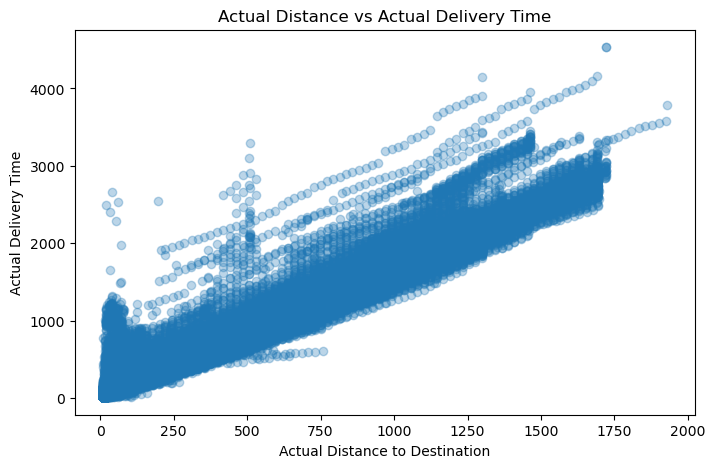

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["actual_distance_to_destination"],
    df["actual_time"],
    alpha=0.3
)

plt.xlabel("Actual Distance to Destination")
plt.ylabel("Actual Delivery Time")
plt.title("Actual Distance vs Actual Delivery Time")

plt.show()

### Distance vs Delivery Time — Key Insights

- Actual distance and actual delivery time show an extremely strong positive correlation of **0.9787**.
- This indicates that longer delivery distances are strongly associated with longer actual delivery times in the dataset.
- Actual distance and OSRM distance also show a very strong correlation of **0.9971**, indicating that the estimated route distances closely follow the actual distances.
- Actual time and OSRM time have a correlation of **0.9780**, showing that expected travel time is strongly related to actual delivery time, although substantial delays still exist.
- The scatter plot confirms the strong upward relationship between distance and actual delivery time.
- However, correlation does not imply that distance alone causes delivery delays. Factors such as route conditions, congestion, source-center operations, and scheduling may also contribute.

**Business takeaway:**  
Distance is a major factor associated with delivery time, but the large gap between actual and expected times indicates that additional operational factors should be investigated to explain delivery inefficiencies.

Business Analysis 7 — Delay Distribution & Outlier Analysis.

In [34]:
# Step 1 — Check the delay distribution
df["delay"].describe()

count    144867.000000
mean        203.059254
std         303.743664
min        -110.000000
25%          21.000000
50%          65.000000
75%         247.000000
max        3137.000000
Name: delay, dtype: float64

In [35]:
# Step 2 — Check how many deliveries were actually delayed
delayed_records = (df["delay"] > 0).sum()
on_time_records = (df["delay"] <= 0).sum()

print("Delayed records:", delayed_records)
print("On-time / early records:", on_time_records)
print("Total records:", len(df))

Delayed records: 141745
On-time / early records: 3122
Total records: 144867


In [39]:
# Step 2 — Identify extreme delays
Q1 = df["delay"].quantile(0.25)
Q3 = df["delay"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 21.0
Q3: 247.0
IQR: 226.0
Lower Bound: -318.0
Upper Bound: 586.0


In [40]:
outliers = df[df["delay"] > upper_bound]

print("Extreme delay records:", len(outliers))
print(
    "Percentage of extreme delays:",
    round(len(outliers) / len(df) * 100, 2),
    "%"
)

Extreme delay records: 16632
Percentage of extreme delays: 11.48 %


Markdown Cell 13 — Delay Distribution & Outlier Analysis

### Delay Distribution & Outlier Analysis — Key Insights

- The dataset contains **144,867 delivery records**, of which **141,745 (97.85%)** experienced a positive delay compared with the expected delivery time.
- The median delay is **65**, while the mean delay is substantially higher at **203.06**, indicating a strongly right-skewed delay distribution.
- The interquartile range (IQR) is **226**, with an upper outlier threshold of **586**.
- **16,632 records (11.48%)** have delays greater than **586**, classifying them as extreme delays using the IQR method.
- The maximum observed delay is **3,137**, showing that a small proportion of deliveries experience exceptionally large delays.
- The negative minimum delay (**-110**) indicates that some deliveries were completed earlier than the expected time.

**Business takeaway:**  
Delivery delays are widespread, but extreme delays are concentrated in a smaller subset of records. These extreme-delay deliveries should be investigated to identify the routes, centers, time periods, and operational factors responsible for major delivery failures.

# Final Business Insights & Recommendations

## Key Business Insights

### 1. Route Type Performance
- Carting and FTL show different delivery performance patterns.
- Carting has a higher relative delay, while FTL has a larger absolute gap between actual and expected delivery time.

### 2. Source Center Performance
- Delivery performance varies considerably across source centers.
- Some centers consistently experience higher delivery delays and should be prioritized for operational investigation.

### 3. Source → Destination Route Performance
- Delivery efficiency varies significantly across routes.
- Certain routes show large gaps between actual and expected delivery time, indicating potential routing or operational inefficiencies.

### 4. Day-of-Week Performance
- Delivery performance remains relatively consistent across the week.
- Wednesday has the highest delay percentage (**97.87%**), while Sunday has the lowest (**91.02%**).

### 5. Time-of-Day Performance
- Delivery performance varies across starting hours.
- 13:00, 17:00, and 22:00 show particularly high average delays and may require closer operational monitoring.

### 6. Distance vs Delivery Time
- Actual distance and actual delivery time have an extremely strong positive correlation (**0.9787**).
- Longer delivery distances are strongly associated with longer delivery times.
- However, distance alone does not explain the complete actual-vs-expected time gap.

### 7. Delay Distribution
- **141,745 of 144,867 records (97.85%)** had actual delivery time greater than expected delivery time.
- Mean delay is **203.06**, compared with a median delay of **65**, indicating a right-skewed distribution.
- **16,632 records (11.48%)** have delays above the IQR-based extreme-delay threshold of **586**.

---

## Business Recommendations

- Prioritize high-volume source centers and routes with consistently high delays.
- Monitor operating periods with high average delays and review scheduling efficiency.
- Evaluate Carting and FTL separately because their delay patterns differ.
- Investigate large actual-vs-expected delivery-time gaps to identify operational inefficiencies.
- Track average delay, delay percentage, and extreme-delay rate as regular logistics KPIs.
- Focus improvement efforts on recurring high-volume problems rather than isolated extreme observations.

## Executive Summary

The analysis indicates that delivery delays are a widespread operational issue. 
Performance varies across route types, source centers, source-to-destination routes, 
days of the week, and starting hours. Distance has a very strong relationship with 
actual delivery time, while the delay distribution shows that a smaller subset of 
deliveries experiences extreme delays.

The analysis suggests that logistics teams should focus on high-volume 
source centers and routes, monitor high-delay operating periods, and track 
actual-versus-expected delivery performance using consistent KPIs.

Dashboard KPIs
# Dashboard KPIs

The following KPIs will be used to summarize overall delivery performance:

1. Total Delivery Records
2. Unique Trips
3. Average Actual Delivery Time
4. Average Expected Delivery Time
5. Average Delay
6. Delay Percentage
7. Delayed Records Percentage
8. Extreme Delay Percentage

In [43]:
total_records = len(df)

unique_trips = df["trip_uuid"].nunique()

avg_actual_time = df["actual_time"].mean()

avg_expected_time = df["osrm_time"].mean()

avg_delay = df["delay"].mean()

delay_pct = (avg_delay / avg_expected_time) * 100

delayed_records_pct = (
    (df["delay"] > 0).sum() / total_records
) * 100

extreme_delay_pct = (
    (df["delay"] > upper_bound).sum() / total_records
) * 100

print("Total Records:", total_records)
print("Unique Trips:", unique_trips)
print("Average Actual Time:", round(avg_actual_time, 2))
print("Average Expected Time:", round(avg_expected_time, 2))
print("Average Delay:", round(avg_delay, 2))
print("Delay Percentage:", round(delay_pct, 2), "%")
print("Delayed Records Percentage:", round(delayed_records_pct, 2), "%")
print("Extreme Delay Percentage:", round(extreme_delay_pct, 2), "%")

Total Records: 144867
Unique Trips: 14817
Average Actual Time: 416.93
Average Expected Time: 213.87
Average Delay: 203.06
Delay Percentage: 94.95 %
Delayed Records Percentage: 97.84 %
Extreme Delay Percentage: 11.48 %


## Dashboard KPI Summary

The following KPIs summarize the overall delivery performance and will be used as the primary metrics in the Power BI dashboard.

In [44]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Records",
        "Unique Trips",
        "Average Actual Time",
        "Average Expected Time",
        "Average Delay",
        "Delay Percentage",
        "Delayed Records Percentage",
        "Extreme Delay Percentage"
    ],
    "Value": [
        total_records,
        unique_trips,
        round(avg_actual_time, 2),
        round(avg_expected_time, 2),
        round(avg_delay, 2),
        round(delay_pct, 2),
        round(delayed_records_pct, 2),
        round(extreme_delay_pct, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Records,144867.00
1,Unique Trips,14817.00
2,Average Actual Time,416.93
3,Average Expected Time,213.87
4,Average Delay,203.06
5,Delay Percentage,94.95
6,Delayed Records Percentage,97.84
7,Extreme Delay Percentage,11.48


In [45]:
df.shape

(144867, 28)

In [46]:
df.columns.tolist()

['data',
 'trip_creation_time',
 'route_schedule_uuid',
 'route_type',
 'trip_uuid',
 'source_center',
 'source_name',
 'destination_center',
 'destination_name',
 'od_start_time',
 'od_end_time',
 'start_scan_to_end_scan',
 'is_cutoff',
 'cutoff_factor',
 'cutoff_timestamp',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'factor',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance',
 'segment_factor',
 'delay',
 'route',
 'day_of_week',
 'start_hour']

# Power BI Dataset Preparation

The cleaned dataset contains 144,867 delivery records and 28 fields.
The dataset includes the original logistics attributes along with derived
business-analysis fields such as delay, route, day of week, and start hour.

A Power BI-ready dataset will be exported for dashboard development.

In [49]:
# Create a copy for Power BI
powerbi_df = df.copy()

print("Power BI dataset shape:", powerbi_df.shape)
print("Columns:", powerbi_df.columns.tolist())

Power BI dataset shape: (144867, 28)
Columns: ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor', 'delay', 'route', 'day_of_week', 'start_hour']


## Power BI Data Type Verification

Before exporting the dataset, verify that numeric, categorical, and datetime
columns have appropriate data types for Power BI.

In [50]:
powerbi_df.dtypes

data                                      object
trip_creation_time                        object
route_schedule_uuid                       object
route_type                                object
trip_uuid                                 object
source_center                             object
source_name                               object
destination_center                        object
destination_name                          object
od_start_time                     datetime64[ns]
od_end_time                               object
start_scan_to_end_scan                   float64
is_cutoff                                   bool
cutoff_factor                              int64
cutoff_timestamp                          object
actual_distance_to_destination           float64
actual_time                              float64
osrm_time                                float64
osrm_distance                            float64
factor                                   float64
segment_actual_time 

## Missing Value Check

Verify that the Power BI dataset does not contain unexpected missing values
in the fields required for dashboard analysis.

In [51]:
missing_summary = (
    powerbi_df.isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["Column", "Missing_Values"]

missing_summary[missing_summary["Missing_Values"] > 0]

,Column,Missing_Values
14,cutoff_timestamp,3429


## Power BI Date-Time Preparation

Convert the logistics timestamp fields to proper datetime format so that
Power BI can recognize them correctly for time-based filtering and analysis.

The 34 missing cutoff timestamps will be retained because they do not affect
the core delivery-performance analysis.

In [52]:
# Convert timestamp columns to datetime
datetime_columns = [
    "trip_creation_time",
    "od_start_time",
    "od_end_time",
    "cutoff_timestamp"
]

for col in datetime_columns:
    powerbi_df[col] = pd.to_datetime(
        powerbi_df[col],
        errors="coerce"
    )

# Verify datetime columns
powerbi_df[datetime_columns].dtypes

trip_creation_time    datetime64[ns]
od_start_time         datetime64[ns]
od_end_time           datetime64[ns]
cutoff_timestamp      datetime64[ns]
dtype: object

## Final Power BI Dataset Validation

Verify the final dataset dimensions, missing values, and data types before
exporting the dataset for dashboard development.

In [53]:
print("Shape:", powerbi_df.shape)

print("\nMissing values:")
print(
    powerbi_df.isna()
    .sum()
    .loc[lambda x: x > 0]
)

print("\nDatetime columns:")
print(powerbi_df[datetime_columns].dtypes)

Shape: (144867, 28)

Missing values:
cutoff_timestamp    3429
dtype: int64

Datetime columns:
trip_creation_time    datetime64[ns]
od_start_time         datetime64[ns]
od_end_time           datetime64[ns]
cutoff_timestamp      datetime64[ns]
dtype: object


In [54]:
powerbi_df.to_csv(
    "delivery_logistics_powerbi.csv",
    index=False
)

print("Power BI dataset exported successfully.")

Power BI dataset exported successfully.


In [55]:
import os

print(os.path.exists("delivery_logistics_powerbi.csv"))

True
